In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os

NETWORKS_DIR = "networks"
FILES_DIR = "files/networks"
FIGURES_DIR = "figures"
ALPHA = 0.1

grey_color = "#595959"
color_E = "#FFA607"  # exploiters
color_V = "#01582C"  # victims

mpl.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": grey_color,
    "axes.labelcolor": grey_color,
    "xtick.color": grey_color,
    "ytick.color": grey_color,
    "text.color": grey_color,
    "axes.titlecolor": grey_color,
})

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs("dataframes", exist_ok=True)


/Users/usuario/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/usuario/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Figures 2 & 3 — synthetic nested network

Reproduces the two illustrative figures built on the synthetic, perfectly
nested 5x5 network (`networks/network_000`, see `networks/README.md`):

- **Figure 2** — trait trajectories `z(t)` for all species, at the four
  `(xi_E, xi_V)` grid corners.
- **Figure 3** — fitness heatmaps over the full `(xi_E, xi_V)` grid, plus
  `z(t)` trajectories of the most/least connected species under two
  contrasting selection regimes ("Scenario A" `xi_E=0.7, xi_V=0.3` and
  "Scenario B" `xi_E=0.3, xi_V=0.7`).

**Generating the required data** (run from the repository root):

```bash
# Heatmaps (Figure 3): final state over the whole (xi_E, xi_V) grid
src/run_coevolution_networks.sh -i 0 -e 0 -t 0

# Trajectories (Figures 2 and 3): full time series over the whole grid
src/run_coevolution_networks.sh -i 0 -e 0 -t 1
```

The full `(xi_E, xi_V)` sweep is 17x17=289 combinations; with `flag_temporal=1`
that means 289 x `N_Sim` x `TMAX/h` rows per species (hundreds of millions of
rows at the paper's defaults). Since this notebook only ever needs 4-6
specific corners (`xi_E, xi_V` in `{0.1, 0.3, 0.7, 0.9}`), it is much cheaper
to temporarily narrow the sweep before compiling — e.g. in the
`CHANGE WHEN NECESSARY` block of `src/coevolution_antagonistic_networks.c`,
set `xi_d_V_delta = xi_d_E_delta = 0.2` (grid `{0.1, 0.3, 0.5, 0.7, 0.9}`)
for the `-t 1` (temporal) run only.

In [2]:
NET_NUM = 0        # networks/network_000: synthetic nested network

def load_network(net_num=NET_NUM, networks_dir=NETWORKS_DIR):
    """Loads networks/network_<net_num>/{adjacency_matrix.csv,metadata.json}."""
    net_dir = f"{networks_dir}/network_{net_num:03d}"
    adjacency = np.loadtxt(f"{net_dir}/adjacency_matrix.csv", delimiter=",", ndmin=2).astype(int)
    with open(f"{net_dir}/metadata.json") as f:
        metadata = json.load(f)
    return adjacency, metadata

def load_final(net_num=NET_NUM, alpha=ALPHA, files_dir=FILES_DIR):
    """Loads Files/networks/network_<net_num>_final_alpha=<alpha>.csv.

    One row per simulation x (xi_E, xi_V) combination, used for the fitness
    heatmaps (produced with flag_temporal=0).
    """
    filename = f"{files_dir}/network_{net_num:03d}_final_alpha={alpha:.1f}.csv"
    df = pd.read_csv(filename, header=6)
    return df.rename(columns={"#net_id": "net_id"}).fillna(0)


def load_temporal(species, net_num=NET_NUM, alpha=ALPHA, files_dir=FILES_DIR):
    """Loads Files/networks/temporal/network_<net_num>_temporal_<species>_alpha=<alpha>.csv.

    `species` is "E" or "V". Unlike the old per-(xi_E, xi_V) temporal files,
    this single file covers the whole (xi_E, xi_V) sweep (produced with
    flag_temporal=1) -- filter by xi_E/xi_V/sim to get one trajectory.
    """
    filename = f"{files_dir}/temporal/network_{net_num:03d}_temporal_{species}_alpha={alpha:.1f}.csv"
    df = pd.read_csv(filename, header=6)
    return df.rename(columns={"#net_id": "net_id"}).fillna(0)


adjacency, metadata = load_network()
M_E, M_V = adjacency.shape
description = metadata["description"]
print(f"network_000: {M_E} exploiters x {M_V} victims -- {description}")

network_000: 5 exploiters x 5 victims -- Synthetic perfectly nested (triangular) bipartite network used to illustrate the trait-based coevolutionary model (Fig. 1a and the Figure 2/3 temporal-dynamics panels), not part of the 122-network empirical dataset in network_001..network_122.


## Figure 2: $z(t)$

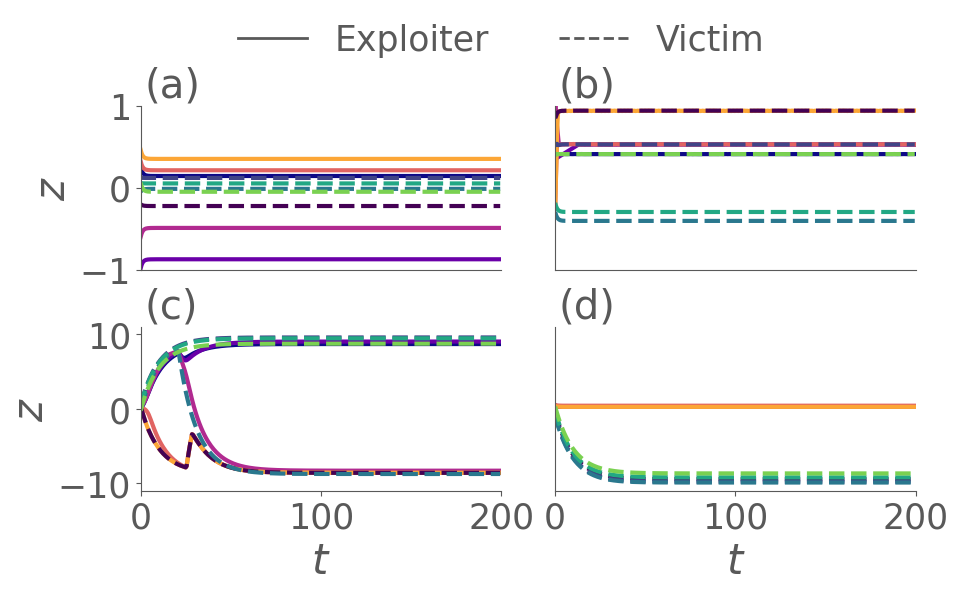

In [13]:
def plot_temp_evol(ax, df_E, df_V, xi_E, xi_V, sim, M_E, M_V, tmax):
    """Plots z(t) for every exploiter (solid, plasma) and victim (dashed, viridis)."""
    sub_E = df_E[(df_E.xi_E == xi_E) & (df_E.xi_V == xi_V) & (df_E.sim == sim) & (df_E.time < tmax)]
    sub_V = df_V[(df_V.xi_E == xi_E) & (df_V.xi_V == xi_V) & (df_V.sim == sim) & (df_V.time < tmax)]

    cmap_E, cmap_V = plt.get_cmap("plasma"), plt.get_cmap("viridis")
    for E_id in range(M_E):
        sns.lineplot(data=sub_E, ax=ax, x="time", y=f"z_E_{E_id}", estimator="mean",
                     lw=3, ls="-", c=cmap_E(E_id / M_E))
    for V_id in range(M_V):
        sns.lineplot(data=sub_V, ax=ax, x="time", y=f"z_V_{V_id}", estimator="mean",
                     lw=3, ls="--", c=cmap_V(V_id / M_V))


tick_label_size = 25
axis_label_size = 30
t_max = 200
n_sim = 1  # valid sim indices are 0..N_Sim-1

df_E_temporal = load_temporal("E")
df_V_temporal = load_temporal("V")

fig = plt.figure(figsize=(10, 5))
layout = [["1_1", "1_9"], ["9_9", "9_1"]]
axes = fig.subplot_mosaic(layout, gridspec_kw={"height_ratios": [1, 1]})
plt.subplots_adjust(hspace=0.35, wspace=0.15)

xiV_array = [0.1, 0.1, 0.9, 0.9]
xiE_array = [0.1, 0.9, 0.9, 0.1]
keys = ["1_1", "1_9", "9_9", "9_1"]
labels = ["(a)", "(b)", "(c)", "(d)"]

for i, key in enumerate(keys):
    ax = axes[key]
    xi_E, xi_V = xiE_array[i], xiV_array[i]
    plot_temp_evol(ax, df_E_temporal, df_V_temporal, xi_E, xi_V, n_sim, M_E, M_V, t_max)

    ax.set_xlim(0, t_max)
    ax.set_ylim(-1., 1.) if i < 2 else ax.set_ylim(-11, 11)

    is_bottom = i >= 2
    is_left = i % 2 == 0

    ax.tick_params(axis="x", labelbottom=is_bottom, bottom=is_bottom, labelsize=tick_label_size)
    ax.tick_params(axis="y", labelleft=is_left, left=is_left, labelsize=tick_label_size)
    ax.set_ylabel("")
    ax.set_xlabel("")

    if is_bottom:
        ax.set_xlabel(r"$t$", fontsize=axis_label_size)
        ax.set_xticks([0, 100, 200])
    if is_left:
        ax.set_ylabel(r"$z$", fontsize=axis_label_size)
    if is_left and is_bottom:
        ax.set_yticks([-10, 0, 10])

    ax.text(0.01, 1.0, labels[i], transform=ax.transAxes, fontsize=29, va="bottom", ha="left")

legend_lines = [plt.Line2D([0], [0], lw=2, linestyle="-", color=grey_color),
                plt.Line2D([0], [0], lw=2, linestyle="--", color=grey_color)]
axes["1_1"].legend(legend_lines, ["Exploiter", "Victim"], bbox_to_anchor=(1.0, 1.4),
                    loc="center", frameon=False, ncol=2, fontsize=25)

for ext in ["png", "svg", "pdf"]:
    fig.savefig(f"{FIGURES_DIR}/Figure_2.{ext}", bbox_inches="tight", dpi=300, transparent=True)
plt.show()

## Figure 3: fitness heatmaps and $z(t)$

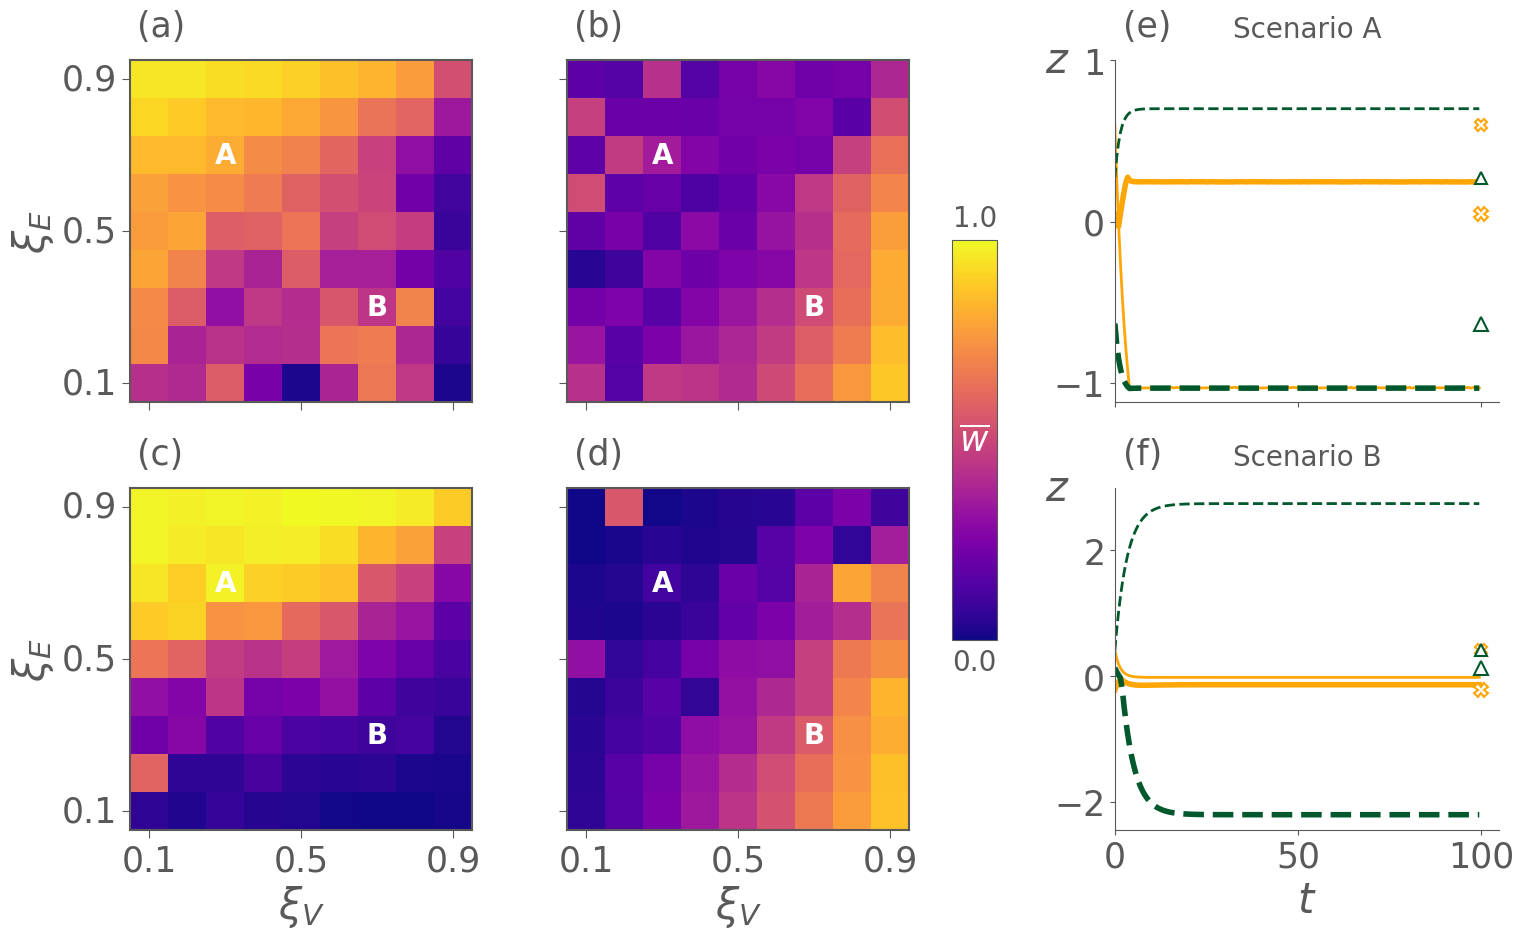

In [14]:
cbar_label_size = 20
t_max_fig3 = 100
n_sim_fig3 = 0

color_ls = ["-", "--"]
xiE_scenarios = [0.7, 0.3]  # [Scenario A, Scenario B]
xiV_scenarios = [0.3, 0.7]

fig = plt.figure(figsize=(18, 10))
subfigs = fig.subfigures(1, 2, width_ratios=[1, 0.33], wspace=-0.2)

axes_hm = subfigs[0].subplot_mosaic(
    [["HM_E_gen", "HM_V_gen"], ["HM_E_spe", "HM_V_spe"]],
    gridspec_kw={"wspace": -0.40, "hspace": 0.25},
)
axes_scen = subfigs[1].subplot_mosaic([["A_scen"], ["B_scen"]], gridspec_kw={"hspace": 0.25})
axes = {**axes_hm, **axes_scen}

panel_labels = {"HM_E_gen": "(a)", "HM_V_gen": "(b)", "HM_E_spe": "(c)", "HM_V_spe": "(d)",
                "A_scen": "(e)", "B_scen": "(f)"}
for key, ax in axes.items():
    ax.text(0.02, 1.05, panel_labels[key], transform=ax.transAxes, fontsize=25, va="bottom", ha="left")

# --- Heatmaps: mean fitness of the most-connected (generalist) and least-connected
# (specialist) species, over the full (xi_E, xi_V) grid ---
df_final = load_final()
df_mean = df_final.groupby(["xi_E", "xi_V"]).mean(numeric_only=True).reset_index()

fit_E = sorted([c for c in df_final.columns if c.startswith("fitness_E_")])
fit_V = sorted([c for c in df_final.columns if c.startswith("fitness_V_")])
species_to_plot = {"HM_E_gen": fit_E[0], "HM_V_gen": fit_V[0], "HM_E_spe": fit_E[-1], "HM_V_spe": fit_V[-1]}

xi_E_list = sorted(df_mean["xi_E"].unique())
xi_V_list = sorted(df_mean["xi_V"].unique())
target_ticks = [0.1, 0.5, 0.9]
x_tick_positions = [xi_V_list.index(v) + 0.5 for v in target_ticks if v in xi_V_list]
y_tick_positions = [xi_E_list.index(e) + 0.5 for e in target_ticks if e in xi_E_list]
tick_labels = [f"{val:.1f}" for val in target_ticks]

for key, col in species_to_plot.items():
    ax = axes[key]
    pivot = df_mean.pivot(index="xi_E", columns="xi_V", values=col)
    # NOTE: no transpose -- pivot already has xi_E on the rows (y) and xi_V on the
    # columns (x), matching the axis labels below; heatmap(pivot.T) previously swapped
    # xi_E/xi_V, which also misplaced the Scenario A/B labels onto the wrong cells.
    sns.heatmap(pivot, ax=ax, cmap="plasma", cbar=False, vmin=0, vmax=1, square=True)
    ax.invert_yaxis()

    show_left = key in ["HM_E_gen", "HM_E_spe"]
    show_bottom = key in ["HM_E_spe", "HM_V_spe"]

    ax.set_xticks(x_tick_positions)
    ax.set_xticklabels(tick_labels, rotation=0, fontsize=tick_label_size)
    ax.set_yticks(y_tick_positions)
    ax.set_yticklabels(tick_labels, rotation=0, fontsize=tick_label_size)
    ax.set_xlabel(r"$\xi_V$" if show_bottom else "", fontsize=axis_label_size)
    ax.set_ylabel(r"$\xi_E$" if show_left else "", fontsize=axis_label_size)
    ax.tick_params(axis="x", which="both", bottom=True, length=6, color=grey_color, labelbottom=show_bottom)
    ax.tick_params(axis="y", which="both", left=True, length=6, color=grey_color, labelleft=show_left)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color(grey_color)
        spine.set_linewidth(1.5)

    for label, ex, vx in [("A", 0.7, 0.3), ("B", 0.3, 0.7)]:
        if ex in xi_E_list and vx in xi_V_list:
            y_pos, x_pos = xi_E_list.index(ex) + 0.5, xi_V_list.index(vx) + 0.5
            ax.text(x_pos, y_pos, label, color="white", weight="bold", ha="center", va="center", fontsize=20)

cbar_ax = subfigs[0].add_axes([0.8, 0.3, 0.03, 0.4])
sm = plt.cm.ScalarMappable(cmap="plasma", norm=plt.Normalize(0, 1))
subfigs[0].colorbar(sm, cax=cbar_ax, ticks=[])
cbar_ax.text(0.5, 1.02, "1.0", transform=cbar_ax.transAxes, fontsize=cbar_label_size, va="bottom", ha="center")
cbar_ax.text(0.5, 0.5, r"$\overline{w}$", c="w", weight="bold", transform=cbar_ax.transAxes,
             fontsize=25, va="center", ha="center")
cbar_ax.text(0.5, -0.02, "0.0", transform=cbar_ax.transAxes, fontsize=cbar_label_size, va="top", ha="center")

# --- Temporal panels: most-connected (thick) and least-connected (thin) species,
# under Scenario A (xi_E=0.7, xi_V=0.3) and Scenario B (xi_E=0.3, xi_V=0.7) ---
for scen_key, scen_idx, scen_title in [("A_scen", 0, "Scenario A"), ("B_scen", 1, "Scenario B")]:
    ax = axes[scen_key]
    show_bottom = scen_key == "B_scen"
    ax.tick_params(axis="x", which="both", bottom=True, top=False, labelbottom=show_bottom, labelsize=tick_label_size)
    ax.tick_params(axis="y", which="both", left=True, right=False, labelleft=True, labelsize=tick_label_size)

    xi_E, xi_V = xiE_scenarios[scen_idx], xiV_scenarios[scen_idx]
    sub_E = df_E_temporal[(df_E_temporal.xi_E == xi_E) & (df_E_temporal.xi_V == xi_V) & (df_E_temporal.sim == n_sim_fig3)]
    sub_V = df_V_temporal[(df_V_temporal.xi_E == xi_E) & (df_V_temporal.xi_V == xi_V) & (df_V_temporal.sim == n_sim_fig3)]

    for E_id, lw, ms in [(0, 4, 10), (M_E - 1, 2, 8)]:
        data = sub_E[sub_E.time < t_max_fig3]
        sns.lineplot(data=data, ax=ax, x="time", y=f"z_E_{E_id}", estimator="mean", lw=lw, ls=color_ls[0], c=color_E)
        theta_E = sub_E[f"theta_E_{E_id}"].iloc[0]
        ax.plot(t_max_fig3, theta_E, marker="X", markerfacecolor="w", markersize=ms, mew=1.5, color=color_E)

    for V_id, lw, ms in [(0, 4, 10), (M_V - 1, 2, 8)]:
        data = sub_V[sub_V.time < t_max_fig3]
        sns.lineplot(data=data, ax=ax, x="time", y=f"z_V_{V_id}", estimator="mean", lw=lw, ls=color_ls[1], c=color_V)
        theta_V = sub_V[f"theta_V_{V_id}"].iloc[0]
        ax.plot(t_max_fig3, theta_V, marker="^", markerfacecolor="w", markersize=ms, mew=1.5, color=color_V)

    ax.set_facecolor("white")
    ax.set_xlim(0, t_max_fig3 + 5)
    ax.set_xlabel(r"$t$" if show_bottom else "", fontsize=axis_label_size)
    ax.set_yticks([-1.0, 0.0, 1.0] if scen_key == "A_scen" else [-2.0, 0.0, 2.0])
    ax.set_ylabel("")
    ax.text(0.5, 1.05, scen_title, transform=ax.transAxes, fontsize=20, va="bottom", ha="center")

axes["A_scen"].text(-0.15, 1., r"$z$", c=grey_color, transform=axes["A_scen"].transAxes, fontsize=30, va="center", ha="center")
axes["B_scen"].text(-0.15, 1., r"$z$", c=grey_color, transform=axes["B_scen"].transAxes, fontsize=30, va="center", ha="center")

for ext in ["png", "svg", "pdf"]:
    fig.savefig(f"{FIGURES_DIR}/Figure_3.{ext}", bbox_inches="tight", dpi=300, transparent=True)
plt.show()


# Figures 4, 5, 6 and SM

This notebook reproduces the empirical-network figures of the paper
 directly from the files published in this repository:

- `networks/network_<001..122>/adjacency_matrix.csv` and `metadata.json` — the
  122 empirical networks (see `networks/README.md`).
- `networks/network_descriptors.csv` — the 8 precomputed structural
  descriptors (`M_E`, `M_V`, `E/V`, `mean_k_E`, `mean_k_V`, `rho_L`, `Q`,
  `NODF`) used in the PCA.
- `Files/networks/network_<001..122>_final_alpha=0.1.csv` — the coevolutionary
  simulation output produced by `src/coevolution_antagonistic_networks.c` for
  each network (100 simulations x grid of `xi_E`, `xi_V`).


## Data loading helpers

In [5]:
NET_NUM = 122

def load_network(net_num, networks_dir=NETWORKS_DIR):
    """Loads networks/network_<net_num>/{adjacency_matrix.csv,metadata.json}.

    Returns the adjacency matrix (rows = exploiters, columns = victims, see
    networks/README.md), its metadata dict, and the per-species degree
    arrays (degree_E has one entry per exploiter, degree_V per victim).
    """
    net_dir = f"{networks_dir}/network_{net_num:03d}"

    adjacency = np.loadtxt(f"{net_dir}/adjacency_matrix.csv", delimiter=",", ndmin=2).astype(int)
    with open(f"{net_dir}/metadata.json") as f:
        metadata = json.load(f)

    degree_E = adjacency.sum(axis=1)  # victims per exploiter
    degree_V = adjacency.sum(axis=0)  # exploiters per victim

    return adjacency, metadata, degree_E, degree_V


def load_simulation_final(net_num, alpha=ALPHA, files_dir=FILES_DIR):
    """Loads Files/networks/network_<net_num>_final_alpha=<alpha>.csv.

    Produced by src/coevolution_antagonistic_networks.c (flag_temporal=0):
    one row per simulation, with theta/z/fitness/fitness_amb/fitness_int for
    every victim and exploiter species. The first 6 lines are a comment
    header (date, seed, number of simulations).
    """
    filename = f"{files_dir}/network_{net_num:03d}_final_alpha={alpha:.1f}.csv"
    df = pd.read_csv(filename, header=6)
    return df.rename(columns={"#net_id": "net_id"}).fillna(0)


def build_species_dataframe(net_num, alpha=ALPHA, networks_dir=NETWORKS_DIR, files_dir=FILES_DIR):
    """Builds a tidy per-species dataframe for one network.

    One row per (xi_E, xi_V, species), averaged over the 100 simulations,
    with columns: species_type, species_index, degree, fitness,
    fitness_amb, fitness_int, network, network_type.
    """
    adjacency, metadata, degree_E, degree_V = load_network(net_num, networks_dir)

    df_final = load_simulation_final(net_num, alpha, files_dir)
    mean_df = df_final.groupby(["xi_E", "xi_V"]).mean(numeric_only=True).reset_index()

    fitness_cols = [c for c in mean_df.columns if c.startswith("fitness")]
    long_df = mean_df.melt(id_vars=["xi_E", "xi_V"], value_vars=fitness_cols,
                            var_name="variable", value_name="value")

    parsed = long_df["variable"].str.extract(r"^fitness(?:_(amb|int))?_([EV])_(\d+)$")
    long_df["metric"] = parsed[0].map({"amb": "fitness_amb", "int": "fitness_int"}).fillna("fitness")
    long_df["species_type"] = parsed[1]
    long_df["species_index"] = parsed[2].astype(int)

    wide_df = long_df.pivot_table(
        index=["xi_E", "xi_V", "species_type", "species_index"],
        columns="metric", values="value",
    ).reset_index()
    wide_df.columns.name = None

    degree_map = {("E", i): d for i, d in enumerate(degree_E)}
    degree_map.update({("V", i): d for i, d in enumerate(degree_V)})
    wide_df["degree"] = [degree_map[(t, i)] for t, i in zip(wide_df.species_type, wide_df.species_index)]

    wide_df["species"] = wide_df["species_type"] + "_" + wide_df["species_index"].astype(str)
    wide_df["network"] = net_num
    wide_df["network_type"] = metadata["interaction_type"]

    return wide_df


def build_all_networks_dataframe(n_networks=NET_NUM, alpha=ALPHA):
    frames = [build_species_dataframe(net_num, alpha) for net_num in range(1, n_networks + 1)]
    return pd.concat(frames, ignore_index=True)


## Build the combined per-species dataframe

One row per network / `(xi_E, xi_V)` / species, built from `Files/networks/network_<id>_final_alpha=0.1.csv`.

In [6]:
df_all = build_all_networks_dataframe()
df_all.to_csv("dataframes/df_networks.csv", index=False)

avg_results = (
    df_all.groupby(["xi_E", "xi_V", "species_type", "network", "network_type"])
    .agg(w_avg=("fitness", "mean"), wamb_avg=("fitness_amb", "mean"), wint_avg=("fitness_int", "mean"))
    .reset_index()
)

df_all.head()

/var/folders/dx/jkb46h4n0hqbh0b96bhs2lyc0000gn/T/ipykernel_52572/543215692.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mean_df = df_final.groupby(["xi_E", "xi_V"]).mean(numeric_only=True).reset_index()
/var/folders/dx/jkb46h4n0hqbh0b96bhs2lyc0000gn/T/ipykernel_52572/543215692.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mean_df = df_final.groupby(["xi_E", "xi_V"]).mean(numeric_only=True).reset_index()
/var/folders/dx/jkb46h4n0hqbh0b96bhs2lyc0000gn/T/ipykernel_52572/543215692.py:45: PerformanceWarning: DataFrame 

,xi_E,xi_V,species_type,species_index,fitness,fitness_amb,fitness_int,degree,species,network,network_type
0,0.1,0.1,E,0,0.385616,0.392234,0.326054,5,E_0,1,bacteria.phage
1,0.1,0.1,E,1,0.409302,0.416400,0.345419,5,E_1,1,bacteria.phage
2,0.1,0.1,E,2,0.438643,0.458046,0.264017,7,E_2,1,bacteria.phage
3,0.1,0.1,E,3,0.457905,0.471397,0.336480,5,E_3,1,bacteria.phage
4,0.1,0.1,V,0,0.384296,0.356227,0.636906,3,V_0,1,bacteria.phage


# Figure 4: correlation between fitness and degree of species

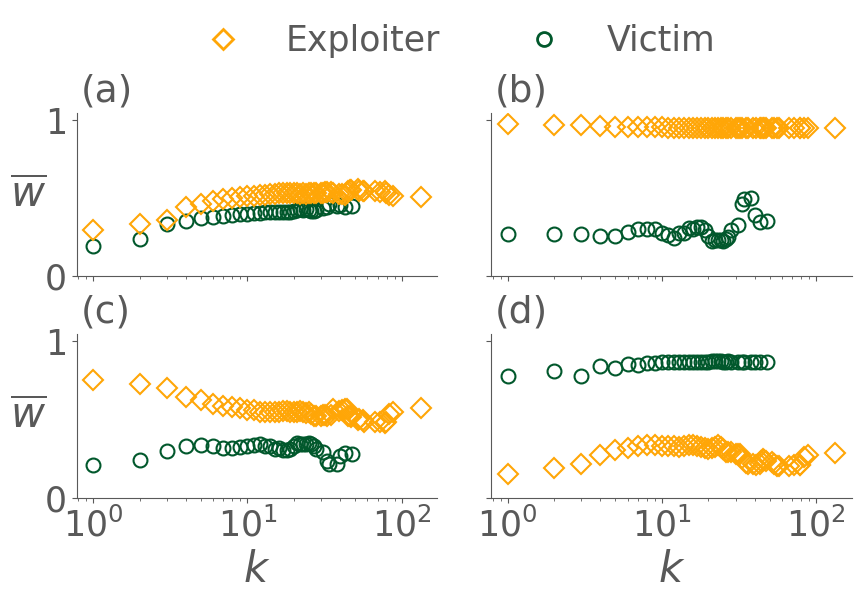

In [7]:
tick_label_size = 25
axis_label_size = 30
label_fontsize = 29
y_min, y_max = 0.0, 1.05

fig = plt.figure(figsize=(10, 5))
layout = [["TL", "TR"], ["BL", "BR"]]
axes = fig.subplot_mosaic(layout, gridspec_kw={"height_ratios": [1, 1], "width_ratios": [1, 1]})
plt.subplots_adjust(hspace=0.35, wspace=0.15)

subsets = {
    "TL": {"xi_V": 0.1, "xi_E": 0.1, "label": "(a)"},
    "TR": {"xi_V": 0.1, "xi_E": 0.9, "label": "(b)"},
    "BL": {"xi_V": 0.9, "xi_E": 0.9, "label": "(c)"},
    "BR": {"xi_V": 0.9, "xi_E": 0.1, "label": "(d)"},
}

for key, cfg in subsets.items():
    ax = axes[key]
    subset = df_all[(df_all["xi_V"] == cfg["xi_V"]) & (df_all["xi_E"] == cfg["xi_E"])]

    show_left = key in ["TL", "BL"]
    show_bottom = key in ["BL", "BR"]

    ax.spines["left"].set_color(grey_color)
    ax.spines["bottom"].set_color(grey_color)
    ax.tick_params(axis="x", bottom=True, top=False, labelbottom=show_bottom, labelsize=tick_label_size)
    ax.tick_params(axis="y", left=True, right=False, labelleft=show_left, labelsize=tick_label_size)
    ax.set_xscale("log")
    ax.set_ylim(y_min, y_max)

    if show_bottom:
        ax.set_xlabel(r"$k$", fontsize=axis_label_size)
    if show_left:
        ax.set_ylabel(r"$\overline{w}$", rotation=0, fontsize=axis_label_size, labelpad=12, va="center")

    for species_type, color, marker, window in [("E", color_E, "D", 5), ("V", color_V, "o", 3)]:
        data = subset[subset["species_type"] == species_type]
        if data.empty:
            continue
        agg = data.groupby("degree", as_index=False)["fitness"].mean()
        agg["window_avg"] = agg["fitness"].rolling(window=window, center=True, min_periods=1).mean()
        ax.plot(agg["degree"], agg["window_avg"], linestyle="", marker=marker, markerfacecolor="none",
                markeredgecolor=color, markersize=10, mew=1.5, zorder=4 if species_type == "E" else 3)

    ax.text(0.01, 1.02, cfg["label"], transform=ax.transAxes, fontsize=label_fontsize - 2,
            va="bottom", ha="left")

legend_elements = [
    plt.Line2D([0], [0], linestyle="", marker="D", markerfacecolor="none", markeredgecolor=color_E, markersize=10, mew=2, label="Exploiter"),
    plt.Line2D([0], [0], linestyle="", marker="o", markerfacecolor="none", markeredgecolor=color_V, markersize=10, mew=2, label="Victim"),
]
fig.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, 1.12), frameon=False, ncol=2, fontsize=25)

for ext in ["svg", "pdf", "png"]:
    fig.savefig(f"{FIGURES_DIR}/Figure_4.{ext}", bbox_inches="tight", dpi=300, transparent=True)
plt.show()

## Análisis estadístico grado-fitness (Fig. 4)

Cuantifica la relación grado-fitness de la Fig. 4 para poder sustituir la
afirmación descriptiva del texto (p. ej. "no relationship emerges between
fitness and degree" para las víctimas) por resultados numéricos con su
significancia.

Dos precisiones sobre el estado actual del notebook antes de este bloque:
- La celda de la Fig. 4 (arriba) todavía **no dibuja ninguna recta de
  ajuste** — solo los puntos de fitness media por valor de grado
  (promedio móvil). La recta y la banda de confianza al 95% se añaden aquí
  por primera vez.
- `df_all` ya cubre las 122 redes y la rejilla completa de `(xi_E, xi_V)`
  (`N_NETWORKS = 122` en la celda de configuración), así que se reutiliza
  directamente sin reconstruir nada.

Se usa `df_all` a nivel de especie individual (no los puntos ya agregados
por clase de grado) para poder ajustar una regresión con errores estándar
robustos por clúster de red: cada red aporta varias especies del mismo
gremio, y sin clusterizar el error estándar de la pendiente se subestima
(la significancia se infla) por tratar esas observaciones como
independientes cuando no lo son.

In [8]:
# --- Regresión log10(grado)-fitness por régimen límite y gremio, clúster-robusta por red ---
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

CORNER_REGIMES_DEG = [(0.1, 0.1), (0.9, 0.1), (0.1, 0.9), (0.9, 0.9)]
GREMIOS_DEG = ["E", "V"]

deg_fit_rows = []
degree_fit_models = {}
for xi_e, xi_v in CORNER_REGIMES_DEG:
    for gremio in GREMIOS_DEG:
        sub = df_all[(df_all["xi_E"] == xi_e) & (df_all["xi_V"] == xi_v)
                     & (df_all["species_type"] == gremio)].copy()
        sub["log_degree"] = np.log10(sub["degree"])
        X = sm.add_constant(sub[["log_degree"]])
        y = sub["fitness"].values
        model = sm.OLS(y, X).fit(cov_type="cluster", cov_kwds={"groups": sub["network"]})
        degree_fit_models[(xi_e, xi_v, gremio)] = model

        rho_spearman, _ = stats.spearmanr(sub["degree"], sub["fitness"])

        deg_fit_rows.append({
            "regimen": f"xiE={xi_e:.1f}_xiV={xi_v:.1f}", "gremio": gremio,
            "n_especies": len(sub), "n_redes": sub["network"].nunique(),
            "pendiente": model.params["log_degree"], "error_std_pendiente": model.bse["log_degree"],
            "R2": model.rsquared, "rho_spearman": rho_spearman, "p_valor": model.pvalues["log_degree"],
        })

deg_fit_summary = pd.DataFrame(deg_fit_rows)
_, p_fdr, _, _ = multipletests(deg_fit_summary["p_valor"], method="fdr_bh")
deg_fit_summary["p_valor_corregido"] = p_fdr

display_cols_deg = ["regimen", "gremio", "pendiente", "error_std_pendiente", "R2",
                     "rho_spearman", "p_valor", "p_valor_corregido"]
print(deg_fit_summary.round(3)[display_cols_deg].to_string(index=False))

deg_fit_summary.round(3)[display_cols_deg].to_csv(f"{FIGURES_DIR}/degree_fitness_stats_summary.csv", index=False)
deg_fit_summary.round(3)[display_cols_deg]

        regimen gremio  pendiente  error_std_pendiente    R2  rho_spearman  p_valor  p_valor_corregido
xiE=0.1_xiV=0.1      E      0.431                0.012 0.794         0.890    0.000              0.000
xiE=0.1_xiV=0.1      V      0.309                0.013 0.770         0.905    0.000              0.000
xiE=0.9_xiV=0.1      E     -0.039                0.001 0.819        -0.901    0.000              0.000
xiE=0.9_xiV=0.1      V      0.022                0.034 0.001         0.283    0.522              0.522
xiE=0.1_xiV=0.9      E      0.308                0.010 0.808         0.888    0.000              0.000
xiE=0.1_xiV=0.9      V      0.008                0.008 0.002        -0.430    0.362              0.414
xiE=0.9_xiV=0.9      E     -0.319                0.007 0.873        -0.899    0.000              0.000
xiE=0.9_xiV=0.9      V      0.165                0.015 0.246         0.525    0.000              0.000


,regimen,gremio,pendiente,error_std_pendiente,R2,rho_spearman,p_valor,p_valor_corregido
0,xiE=0.1_xiV=0.1,E,0.431,0.012,0.794,0.890,0.000,0.000
1,xiE=0.1_xiV=0.1,V,0.309,0.013,0.770,0.905,0.000,0.000
2,xiE=0.9_xiV=0.1,E,-0.039,0.001,0.819,-0.901,0.000,0.000
3,xiE=0.9_xiV=0.1,V,0.022,0.034,0.001,0.283,0.522,0.522
4,xiE=0.1_xiV=0.9,E,0.308,0.010,0.808,0.888,0.000,0.000
5,xiE=0.1_xiV=0.9,V,0.008,0.008,0.002,-0.430,0.362,0.414
6,xiE=0.9_xiV=0.9,E,-0.319,0.007,0.873,-0.899,0.000,0.000
7,xiE=0.9_xiV=0.9,V,0.165,0.015,0.246,0.525,0.000,0.000


### Fig. 4 actualizada (vista previa)

Misma figura, mismo estilo visual, con la recta de ajuste
(`fitness ~ log10(grado)`, errores clúster-robustos) y su banda de
confianza al 95% superpuestas sobre los puntos ya existentes. Se guarda
como `Figure_4_extra.{svg,pdf,png}`, sin modificar `Figure_4.{svg,pdf,png}`.

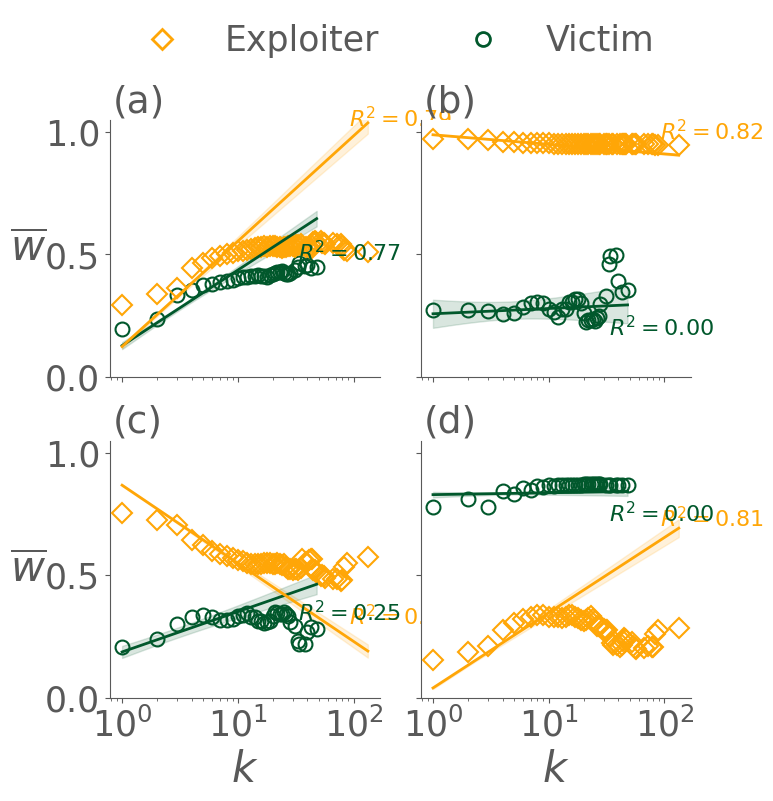

Figura guardada como Figure_4_extra.{svg,pdf,png}; Figure_4.* no se ha modificado.


In [9]:
# --- Figura 4 actualizada: recta de ajuste + banda de confianza 95% (VISTA PREVIA) ---
fig = plt.figure(figsize=(7.5, 7.5))
axes = fig.subplot_mosaic(layout, gridspec_kw={"height_ratios": [1, 1], "width_ratios": [1, 1]})
plt.subplots_adjust(hspace=0.25, wspace=0.15)

for key, cfg in subsets.items():
    ax = axes[key]
    xi_e, xi_v = cfg["xi_E"], cfg["xi_V"]
    subset = df_all[(df_all["xi_V"] == xi_v) & (df_all["xi_E"] == xi_e)]

    show_left = key in ["TL", "BL"]
    show_bottom = key in ["BL", "BR"]

    ax.spines["left"].set_color(grey_color)
    ax.spines["bottom"].set_color(grey_color)
    ax.tick_params(axis="x", bottom=True, top=False, labelbottom=show_bottom, labelsize=tick_label_size)
    ax.tick_params(axis="y", left=True, right=False, labelleft=show_left, labelsize=tick_label_size)
    ax.set_xscale("log")
    ax.set_ylim(y_min, y_max)

    if show_bottom:
        ax.set_xlabel(r"$k$", fontsize=axis_label_size)
    if show_left:
        ax.set_ylabel(r"$\overline{w}$", rotation=0, fontsize=axis_label_size, labelpad=12, va="center")

    for species_type, color, marker, window in [("E", color_E, "D", 5), ("V", color_V, "o", 3)]:
        data = subset[subset["species_type"] == species_type]
        if data.empty:
            continue
        agg = data.groupby("degree", as_index=False)["fitness"].mean()
        agg["window_avg"] = agg["fitness"].rolling(window=window, center=True, min_periods=1).mean()
        ax.plot(agg["degree"], agg["window_avg"], linestyle="", marker=marker, markerfacecolor="none",
                markeredgecolor=color, markersize=10, mew=1.5, zorder=4 if species_type == "E" else 3)

        model = degree_fit_models[(xi_e, xi_v, species_type)]
        deg_grid = np.linspace(data["degree"].min(), data["degree"].max(), 100)
        X_grid = sm.add_constant(pd.DataFrame({"log_degree": np.log10(deg_grid)}))
        pred = model.get_prediction(X_grid)
        ci_low, ci_high = pred.conf_int(alpha=0.05).T
        ax.plot(deg_grid, pred.predicted_mean, color=color, linewidth=2,
                 zorder=6 if species_type == "E" else 5)
        ax.fill_between(deg_grid, ci_low, ci_high, color=color, alpha=0.15, zorder=0)

        label_idx = int(len(deg_grid) * 0.68)
        y_offset = (y_max - y_min) * 0.035 * (1 if species_type == "E" else -1)
        ax.text(deg_grid[label_idx], pred.predicted_mean[label_idx] + y_offset,
                f"$R^2={model.rsquared:.2f}$", color=color, fontsize=tick_label_size - 9,
                weight="bold", ha="left", va="bottom" if species_type == "E" else "top", zorder=7)

    ax.text(0.01, 1.0, cfg["label"], transform=ax.transAxes, fontsize=label_fontsize - 2,
            va="bottom", ha="left")

fig.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, 1.05), frameon=False, ncol=2, fontsize=25)

for ext in ["svg", "pdf", "png"]:
    fig.savefig(f"{FIGURES_DIR}/Figure_4_extra.{ext}", bbox_inches="tight", dpi=300, transparent=True)
plt.show()

print("Figura guardada como Figure_4_extra.{svg,pdf,png}; Figure_4.* no se ha modificado.")

# Principal Component Analysis (PCA)

In [10]:
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

network_props = pd.read_csv(f"{NETWORKS_DIR}/network_descriptors.csv")
network_props["network"] = np.arange(1, len(network_props) + 1)

feature_cols = ["Q", "NODF", "mean_k_E", "mean_k_V", "E/V", "rho_L", "M_E", "M_V"]
metrics_names = [r"$Q_{HSP}$", r"$NODF$", r"$\langle k_E\rangle$", r"$\langle k_V\rangle$",
                 r"$E/V$", r"$\rho_L$", r"$M_E$", r"$M_V$"]

pca_features = network_props[feature_cols]

pca_pipe = make_pipeline(StandardScaler(), PCA())
pca_pipe.fit(pca_features)
modelo_pca = pca_pipe.named_steps["pca"]

PCA_df = pd.DataFrame(
    data=modelo_pca.components_,
    columns=feature_cols,
    index=[f"PC_{i}" for i in range(len(feature_cols))],
)
explained_variance = modelo_pca.explained_variance_ratio_

# Weighted ranking of metrics by contribution to the first 3 PCs
PCA_weighted_df = (PCA_df.T * explained_variance) ** 2
ranking_df = PCA_weighted_df.iloc[:, :3].sum(axis=1)
ranking_df = (ranking_df / ranking_df.sum()).sort_values(ascending=False)

df_scaled = (pca_features - pca_features.mean()) / pca_features.std()
W = PCA_df.T  # loadings matrix

ranking_df

Q           0.168071
rho_L       0.166977
NODF        0.149191
M_E         0.130070
E/V         0.110134
mean_k_E    0.097855
mean_k_V    0.091718
M_V         0.085985
dtype: float64

# Figure 5: PCA 2D

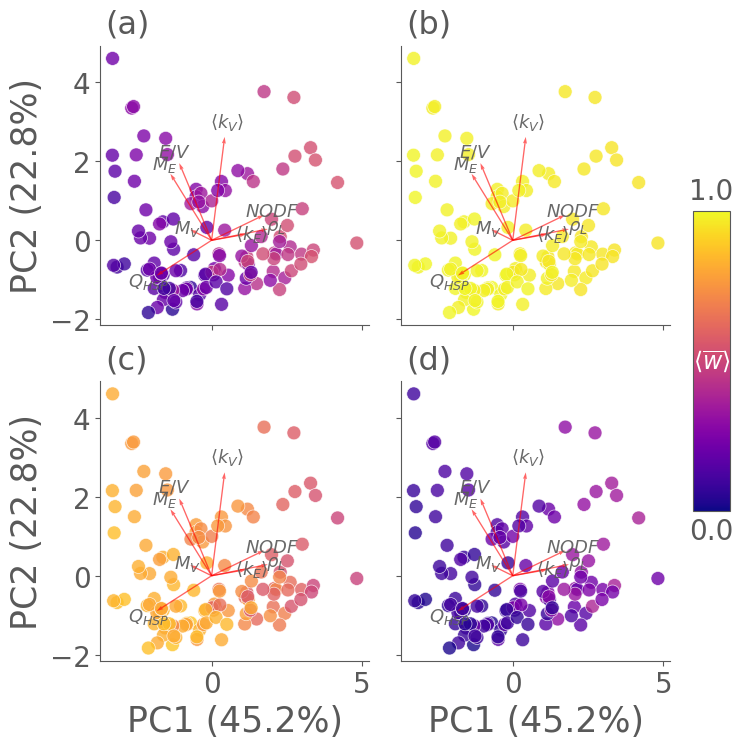

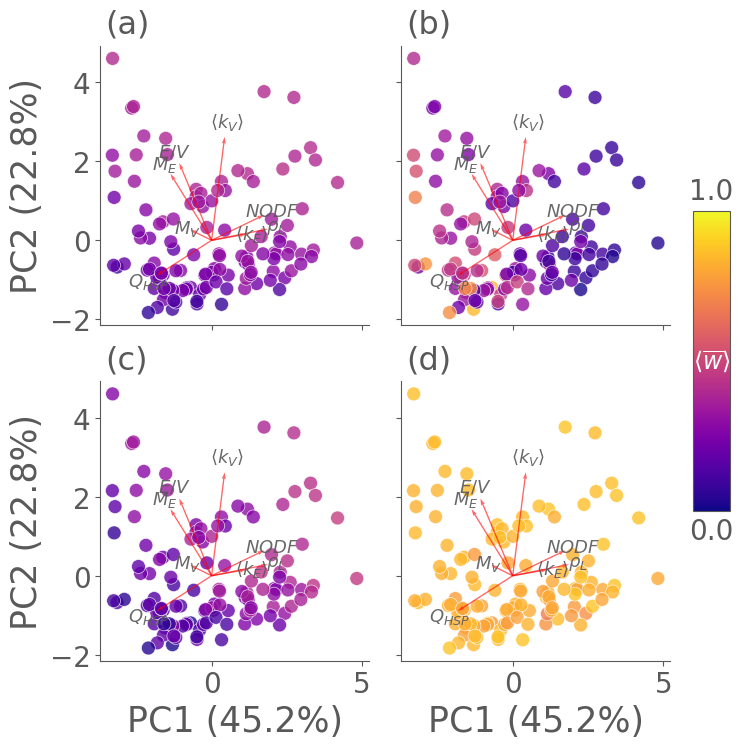

In [11]:
def plot_pca_2d_quadrants(species_type, scores_df, weight_matrix, result_data, explained_var):
    """Combined 2D PCA figure (PC1 vs PC2) for the 4 (xi_E, xi_V) corners."""

    quadrants = {
        "TL": {"params": (0.1, 0.1), "grid_pos": 1, "title": "(a)"},
        "TR": {"params": (0.9, 0.1), "grid_pos": 2, "title": "(b)"},
        "BL": {"params": (0.9, 0.9), "grid_pos": 3, "title": "(c)"},
        "BR": {"params": (0.1, 0.9), "grid_pos": 4, "title": "(d)"},
    }

    arrow_scale = np.max(scores_df[["PC1", "PC2"]].values) * 0.8
    fig = plt.figure(figsize=(7.5, 7.5))
    scatter_handle = None

    tick_label_size, axis_label_size, label_fontsize = 20, 25, 25

    for name, cfg in quadrants.items():
        xi_e, xi_v = cfg["params"]
        subset = result_data[(result_data["xi_E"] == xi_e) & (result_data["xi_V"] == xi_v)
                              & (result_data["species_type"] == species_type)]

        ax = fig.add_subplot(2, 2, cfg["grid_pos"])
        show_left = name in ["TL", "BL"]
        show_bottom = name in ["BL", "BR"]

        scatter_handle = ax.scatter(scores_df["PC1"], scores_df["PC2"], c=subset["w_avg"], cmap="plasma",
                                     s=100, edgecolors="white", linewidth=0.5, alpha=0.8, zorder=1, vmin=0, vmax=1)

        for i, metric in enumerate(metrics_names):
            x, y = weight_matrix.iloc[i, :2]
            ax.quiver(0, 0, x * arrow_scale, y * arrow_scale, angles="xy", scale_units="xy", scale=1,
                      color="red", alpha=0.6, width=0.005, zorder=20)
            ax.text(x * arrow_scale * 1.15, y * arrow_scale * 1.15, metric, fontsize=tick_label_size - 7,
                    weight="bold", alpha=0.9, zorder=30, ha="center", va="center")

        ax.set_xlabel(f"PC1 ({explained_var[0]:.1%})" if show_bottom else "", fontsize=axis_label_size)
        ax.set_ylabel(f"PC2 ({explained_var[1]:.1%})" if show_left else "", fontsize=axis_label_size)
        ax.tick_params(axis="x", bottom=True, top=False, labelbottom=show_bottom, labelsize=tick_label_size)
        ax.tick_params(axis="y", left=True, right=False, labelleft=show_left, labelsize=tick_label_size)
        ax.text(0.02, 1.02, cfg["title"], transform=ax.transAxes, fontsize=label_fontsize - 2, va="bottom", ha="left")

    fig.subplots_adjust(left=0.10, right=0.86, bottom=0.10, top=0.92, wspace=0.12, hspace=0.2)

    cbar_ax = fig.add_axes([0.89, 0.3, 0.05, 0.4])
    sm = plt.cm.ScalarMappable(cmap="plasma", norm=plt.Normalize(0, 1))
    fig.colorbar(sm, cax=cbar_ax, ticks=[])
    cbar_ax.text(0.5, 1.02, "1.0", transform=cbar_ax.transAxes, fontsize=20, va="bottom", ha="center")
    cbar_ax.text(0.5, 0.5, r"$\langle\overline{w}\rangle$", c="w", weight="bold", transform=cbar_ax.transAxes,
                 fontsize=17, va="center", ha="center")
    cbar_ax.text(0.5, -0.02, "0.0", transform=cbar_ax.transAxes, fontsize=20, va="top", ha="center")

    for ext in ["png", "pdf", "svg"]:
        fig.savefig(f"{FIGURES_DIR}/Figure_5_PCA_2D_{species_type}.{ext}", bbox_inches="tight", dpi=300, transparent=True)
    plt.show()


scores_2d = df_scaled.dot(W.iloc[:, :2])
scores_2d.columns = ["PC1", "PC2"]

for species_type in ["E", "V"]:
    plot_pca_2d_quadrants(species_type, scores_2d, W, avg_results, explained_variance)


# Figure 7 (SM): PCA 3D and loadings of metrics to PCs

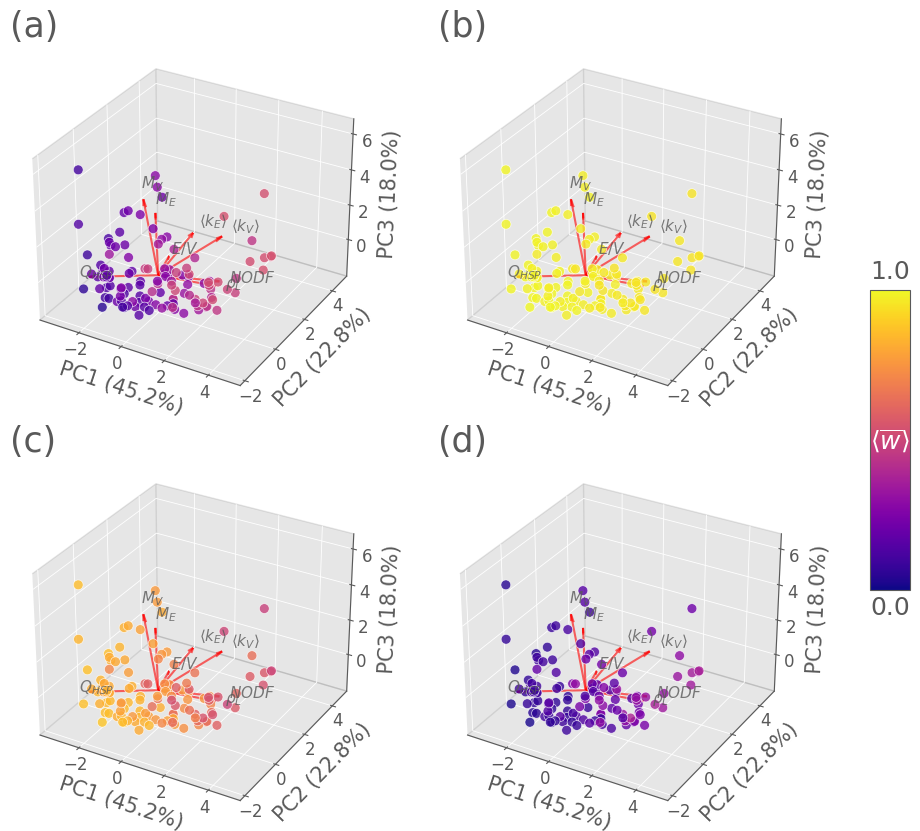

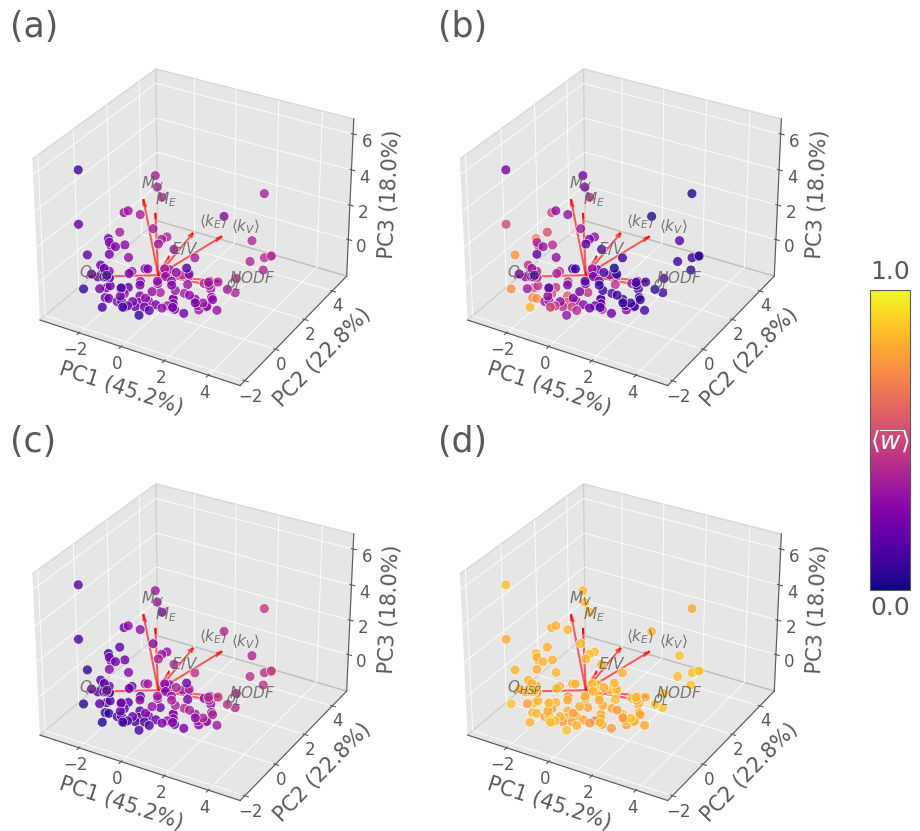

In [12]:
from matplotlib.colors import to_rgba

def plot_pca_3d_quadrants(species_type, scores_df, weight_matrix, result_data, explained_var):
    """Combined 3D PCA figure (PC1, PC2, PC3) for the 4 (xi_E, xi_V) corners."""

    quadrants = {
        "TL": {"params": (0.1, 0.1), "grid_pos": 1, "title": "(a)"},
        "TR": {"params": (0.9, 0.1), "grid_pos": 2, "title": "(b)"},
        "BL": {"params": (0.9, 0.9), "grid_pos": 3, "title": "(c)"},
        "BR": {"params": (0.1, 0.9), "grid_pos": 4, "title": "(d)"},
    }

    arrow_scale = np.max(scores_df.values) * 0.8
    fig = plt.figure(figsize=(10, 15))
    scatter_handle = None

    for name, cfg in quadrants.items():
        xi_e, xi_v = cfg["params"]
        subset = result_data[(result_data["xi_E"] == xi_e) & (result_data["xi_V"] == xi_v)
                              & (result_data["species_type"] == species_type)]

        ax = fig.add_subplot(2, 2, cfg["grid_pos"], projection="3d")
        ax.set_box_aspect((1, 1, 0.8))

        grid_style = {"color": (1, 1, 1, 1), "linewidth": 0.6}
        ax.xaxis._axinfo["grid"].update(grid_style)
        ax.yaxis._axinfo["grid"].update(grid_style)
        ax.zaxis._axinfo["grid"].update(grid_style)

        pane_color = to_rgba(grey_color, alpha=0.15)
        ax.xaxis.set_pane_color(pane_color)
        ax.yaxis.set_pane_color(pane_color)
        ax.zaxis.set_pane_color(pane_color)

        scatter_handle = ax.scatter(scores_df["PC1"], scores_df["PC2"], scores_df["PC3"], c=subset["w_avg"],
                                     cmap="plasma", s=50, edgecolors="white", linewidth=0.5, alpha=0.8,
                                     zorder=1, vmin=0, vmax=1)

        for i, metric in enumerate(metrics_names):
            x, y, z = weight_matrix.iloc[i, :3]
            ax.quiver(0, 0, 0, x * arrow_scale, y * arrow_scale, z * arrow_scale, color="red", alpha=0.6,
                      lw=1.5, arrow_length_ratio=0.1, zorder=20)
            ax.text(x * arrow_scale * 1.15, y * arrow_scale * 1.15, z * arrow_scale * 1.15, metric,
                    fontsize=11, weight="bold", alpha=0.8, zorder=30)

        ax.set_xlabel(f"PC1 ({explained_var[0]:.1%})", labelpad=-3, fontsize=15)
        ax.set_ylabel(f"PC2 ({explained_var[1]:.1%})", labelpad=-3, fontsize=15)
        ax.set_zlabel(f"PC3 ({explained_var[2]:.1%})", labelpad=-3, fontsize=15)
        ax.xaxis.set_tick_params(labelsize=12, pad=-4)
        ax.yaxis.set_tick_params(labelsize=12, pad=-4)
        ax.zaxis.set_tick_params(labelsize=12, pad=-2)
        ax.set_title(cfg["title"], loc="left", pad=-5, fontsize=25, color=grey_color)

    fig.subplots_adjust(left=0.05, right=0.84, bottom=0.12, top=0.95, wspace=0.18, hspace=-0.5)

    cbar_ax = fig.add_axes([0.91, 0.43, 0.04, 0.2])
    sm = plt.cm.ScalarMappable(cmap="plasma", norm=plt.Normalize(0, 1))
    fig.colorbar(sm, cax=cbar_ax, ticks=[])
    cbar_ax.text(0.5, 1.02, "1.0", transform=cbar_ax.transAxes, fontsize=18, va="bottom", ha="center")
    cbar_ax.text(0.5, 0.5, r"$\langle\overline{w}\rangle$", c="w", weight="bold", transform=cbar_ax.transAxes,
                 fontsize=18, va="center", ha="center")
    cbar_ax.text(0.5, -0.02, "0.0", transform=cbar_ax.transAxes, fontsize=18, va="top", ha="center")

    for ext in ["png", "svg", "pdf"]:
        fig.savefig(f"{FIGURES_DIR}/Figure_7_PCA_3D_{species_type}.{ext}", bbox_inches="tight", dpi=300, transparent=True)
    plt.show()


scores_3d = df_scaled.dot(W.iloc[:, :3])
scores_3d.columns = ["PC1", "PC2", "PC3"]

for species_type in ["E", "V"]:
    plot_pca_3d_quadrants(species_type, scores_3d, W, avg_results, explained_variance)


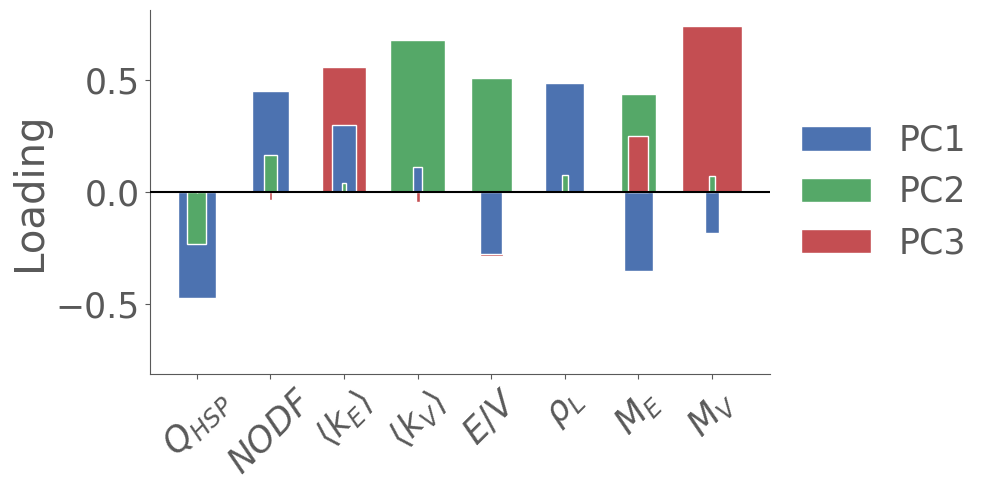

In [13]:
# --- Loadings of each metric on PC1, PC2, PC3 ---
loadings_df = W.iloc[:len(metrics_names), :3].copy()
loadings_df.columns = ["PC1", "PC2", "PC3"]
loadings_df.index = metrics_names

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#4C72B0", "#55A868", "#C44E52"]
labels = ["PC1", "PC2", "PC3"]

for i, metric in enumerate(metrics_names):
    vals = loadings_df.loc[metric].values
    abs_vals = np.abs(vals)
    order = np.argsort(abs_vals)[::-1]  # widest (largest |loading|) drawn first, at the back

    for rank, pc_idx in enumerate(order):
        ax.bar(i, vals[pc_idx], width=1.1 * abs_vals[pc_idx], color=colors[pc_idx], edgecolor="white",
               linewidth=1, zorder=rank, label=labels[pc_idx] if i == 0 else "")

ax.set_xticks(np.arange(len(metrics_names)))
ax.set_xticklabels(metrics_names, fontsize=25, rotation=45)
ax.axhline(0, color="black", linewidth=1.5, zorder=11)
ax.set_ylim(-0.81, 0.81)
ax.set_ylabel("Loading", fontsize=29)
ax.tick_params(axis="y", left=True, right=False, labelsize=25)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False, fontsize=25)
ax.grid(False)

plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/Figure_7_PCA_loadings.png", dpi=300, transparent=True)
fig.savefig(f"{FIGURES_DIR}/Figure_7_PCA_loadings.pdf", dpi=300, transparent=True)
plt.show()


## Análisis estadístico PCA-fitness (bloque 2)

Sustituye las afirmaciones descriptivas de las Figs. 5/7 (PCA vs. fitness) por
un análisis cuantitativo de la relación entre las coordenadas PCA de las 122
redes empíricas y la fitness media por red.

Las celdas de la sección anterior (`df_all`, `avg_results`) solo cubren
`N_NETWORKS` redes, el valor fijado en la celda de configuración inicial
(actualmente 4), y la rejilla de simulación de esas celdas no cubre
`xi_V = 0.9`. Para este bloque se reconstruye la fitness media por red usando
las mismas funciones ya definidas arriba (`build_all_networks_dataframe`),
esta vez con las 122 redes y la rejilla completa de `(xi_E, xi_V)`, y se
combina con los scores de PCA (`scores_3d`) y los tamaños de gremio (`M_E`,
`M_V`) de `network_props`, ambos ya calculados en la sección de PCA.

In [14]:
# --- Datos: fitness media por red, 122 redes x rejilla completa de (xi_E, xi_V) ---
N_NETWORKS_STATS = 122

df_all_full = build_all_networks_dataframe(n_networks=N_NETWORKS_STATS)
avg_results_full = (
    df_all_full.groupby(["xi_E", "xi_V", "species_type", "network", "network_type"])
    .agg(w_avg=("fitness", "mean"), wamb_avg=("fitness_amb", "mean"), wint_avg=("fitness_int", "mean"))
    .reset_index()
)

pca_scores_df = scores_3d.copy()
pca_scores_df["network"] = network_props["network"].values

merged_full = avg_results_full.merge(pca_scores_df, on="network").merge(
    network_props[["network", "M_E", "M_V"]], on="network"
)

PC_COLS = ["PC1", "PC2", "PC3"]
CORNER_REGIMES = [(0.1, 0.1), (0.9, 0.1), (0.1, 0.9), (0.9, 0.9)]
GREMIOS = ["E", "V"]

print(f"merged_full: {merged_full.shape[0]} filas, {merged_full['network'].nunique()} redes, "
      f"grid xi_E={sorted(merged_full['xi_E'].unique())}, xi_V={sorted(merged_full['xi_V'].unique())}")
merged_full.head()

/var/folders/dx/jkb46h4n0hqbh0b96bhs2lyc0000gn/T/ipykernel_52572/543215692.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mean_df = df_final.groupby(["xi_E", "xi_V"]).mean(numeric_only=True).reset_index()
/var/folders/dx/jkb46h4n0hqbh0b96bhs2lyc0000gn/T/ipykernel_52572/543215692.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mean_df = df_final.groupby(["xi_E", "xi_V"]).mean(numeric_only=True).reset_index()
/var/folders/dx/jkb46h4n0hqbh0b96bhs2lyc0000gn/T/ipykernel_52572/543215692.py:45: PerformanceWarning: DataFrame 

merged_full: 70516 filas, 122 redes, grid xi_E=[0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9], xi_V=[0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]


,xi_E,xi_V,species_type,network,network_type,w_avg,wamb_avg,wint_avg,PC1,PC2,PC3,M_E,M_V
0,0.1,0.1,E,1,bacteria.phage,0.422867,0.434519,0.317993,1.494154,-1.096017,-0.365772,4,10
1,0.1,0.1,E,2,host.parasite,0.335539,0.327474,0.408119,1.191345,1.686667,-1.281921,19,7
2,0.1,0.1,E,3,host.parasite,0.142507,0.111282,0.423525,-0.224979,-0.886480,-0.916907,10,7
3,0.1,0.1,E,4,plant.herbivor,0.477057,0.492900,0.334469,0.121962,-0.780719,1.036351,22,52
4,0.1,0.1,E,5,host.parasite,0.478650,0.493831,0.342017,1.166684,-0.418415,0.927818,18,46


### 1-3. Correlaciones, regresión OLS y correlación parcial por régimen límite y gremio

Para los 4 escenarios límite `(xi_E, xi_V) in {0.1, 0.9}^2` y cada gremio: Pearson
r y Spearman rho entre `w_avg` y cada PC por separado, regresión múltiple OLS
`w_avg ~ PC1 + PC2 + PC3` (PCs estandarizadas), y correlación parcial de PC1
controlando por `M_E`, `M_V` (bloque 3). Corrección FDR (Benjamini-Hochberg)
sobre el conjunto completo de p-valores del bloque.

In [15]:
# --- Bloque 1+3: correlaciones, OLS estandarizada y correlación parcial (PC1 | M_E, M_V) ---
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
import pingouin as pg

rows = []
for xi_e, xi_v in CORNER_REGIMES:
    for gremio in GREMIOS:
        sub = merged_full[(merged_full["xi_E"] == xi_e) & (merged_full["xi_V"] == xi_v)
                           & (merged_full["species_type"] == gremio)]
        y = sub["w_avg"].values
        Xz = (sub[PC_COLS] - sub[PC_COLS].mean()) / sub[PC_COLS].std()
        Xz_const = sm.add_constant(Xz)
        model = sm.OLS(y, Xz_const).fit()
        r2_adj_modelo = model.rsquared_adj

        for pc in PC_COLS:
            r_pearson, p_pearson = stats.pearsonr(sub["w_avg"], sub[pc])
            rho_spearman, p_spearman = stats.spearmanr(sub["w_avg"], sub[pc])
            rows.append({
                "regimen": f"xiE={xi_e:.1f}_xiV={xi_v:.1f}",
                "gremio": gremio,
                "PC": pc,
                "r_pearson": r_pearson, "p_pearson": p_pearson,
                "rho_spearman": rho_spearman, "p_spearman": p_spearman,
                "beta_std": model.params[pc], "p_beta": model.pvalues[pc],
                "R2_adj_modelo": r2_adj_modelo,
            })

summary_table = pd.DataFrame(rows)

# Correlación parcial PC1-fitness controlando M_E, M_V (bloque 3); se añade a la fila PC1
partial_rows = []
for xi_e, xi_v in CORNER_REGIMES:
    for gremio in GREMIOS:
        sub = merged_full[(merged_full["xi_E"] == xi_e) & (merged_full["xi_V"] == xi_v)
                           & (merged_full["species_type"] == gremio)]
        pc_res = pg.partial_corr(data=sub, x="PC1", y="w_avg", covar=["M_E", "M_V"], method="pearson")
        partial_rows.append({
            "regimen": f"xiE={xi_e:.1f}_xiV={xi_v:.1f}", "gremio": gremio,
            "r_partial_PC1_MEV": pc_res["r"].iloc[0], "p_partial_PC1_MEV": pc_res["p_val"].iloc[0],
        })
partial_table = pd.DataFrame(partial_rows)

summary_table = summary_table.merge(partial_table, on=["regimen", "gremio"], how="left")
summary_table.loc[summary_table["PC"] != "PC1", ["r_partial_PC1_MEV", "p_partial_PC1_MEV"]] = np.nan

# Corrección FDR (Benjamini-Hochberg) sobre el conjunto completo de p-valores de este bloque
p_cols = ["p_pearson", "p_spearman", "p_beta", "p_partial_PC1_MEV"]
flat_idx = [(idx, col) for col in p_cols for idx, v in summary_table[col].items() if pd.notna(v)]
flat_p = [summary_table.loc[idx, col] for idx, col in flat_idx]
_, p_fdr, _, _ = multipletests(flat_p, method="fdr_bh")
for (idx, col), p_corr in zip(flat_idx, p_fdr):
    summary_table.loc[idx, col + "_fdr"] = p_corr

# Alias legibles pedidos en el formato de salida (p_valor = p del beta estandarizado)
summary_table["p_valor"] = summary_table["p_beta"]
summary_table["p_valor_corregido"] = summary_table["p_beta_fdr"]

display_cols = ["regimen", "gremio", "PC", "r_pearson", "rho_spearman", "beta_std",
                 "R2_adj_modelo", "p_valor", "p_valor_corregido",
                 "r_partial_PC1_MEV", "p_partial_PC1_MEV"]
print(summary_table.round(3)[display_cols].to_string(index=False))

summary_table.round(3).to_csv(f"{FIGURES_DIR}/pca_fitness_stats_summary.csv", index=False)
summary_table.round(3)[display_cols]

        regimen gremio  PC  r_pearson  rho_spearman  beta_std  R2_adj_modelo  p_valor  p_valor_corregido  r_partial_PC1_MEV  p_partial_PC1_MEV
xiE=0.1_xiV=0.1      E PC1      0.800         0.757     0.110          0.768    0.000              0.000              0.866              0.000
xiE=0.1_xiV=0.1      E PC2      0.286         0.398     0.039          0.768    0.000              0.000                NaN                NaN
xiE=0.1_xiV=0.1      E PC3      0.227         0.247     0.031          0.768    0.000              0.000                NaN                NaN
xiE=0.1_xiV=0.1      V PC1      0.368         0.359     0.030          0.742    0.000              0.000              0.711              0.000
xiE=0.1_xiV=0.1      V PC2      0.778         0.841     0.064          0.742    0.000              0.000                NaN                NaN
xiE=0.1_xiV=0.1      V PC3     -0.090        -0.082    -0.007          0.742    0.054              0.063                NaN                NaN

,regimen,gremio,PC,r_pearson,rho_spearman,beta_std,R2_adj_modelo,p_valor,p_valor_corregido,r_partial_PC1_MEV,p_partial_PC1_MEV
0,xiE=0.1_xiV=0.1,E,PC1,0.800,0.757,0.110,0.768,0.000,0.000,0.866,0.000
1,xiE=0.1_xiV=0.1,E,PC2,0.286,0.398,0.039,0.768,0.000,0.000,NaN,NaN
2,xiE=0.1_xiV=0.1,E,PC3,0.227,0.247,0.031,0.768,0.000,0.000,NaN,NaN
3,xiE=0.1_xiV=0.1,V,PC1,0.368,0.359,0.030,0.742,0.000,0.000,0.711,0.000
4,xiE=0.1_xiV=0.1,V,PC2,0.778,0.841,0.064,0.742,0.000,0.000,NaN,NaN
5,xiE=0.1_xiV=0.1,V,PC3,-0.090,-0.082,-0.007,0.742,0.054,0.063,NaN,NaN
6,xiE=0.9_xiV=0.1,E,PC1,-0.828,-0.788,-0.010,0.771,0.000,0.000,-0.867,0.000
7,xiE=0.9_xiV=0.1,E,PC2,-0.184,-0.289,-0.002,0.771,0.000,0.000,NaN,NaN
8,xiE=0.9_xiV=0.1,E,PC3,-0.240,-0.244,-0.003,0.771,0.000,0.000,NaN,NaN
9,xiE=0.9_xiV=0.1,V,PC1,-0.690,-0.744,-0.128,0.595,0.000,0.000,-0.762,0.000


### 2. Mapa de R² sobre toda la rejilla (xi_E, xi_V)

Para cada una de las 17x17 combinaciones simuladas de `(xi_E, xi_V)` (no solo
los 4 escenarios límite), se ajusta el mismo modelo
`w_avg ~ PC1 + PC2 + PC3` y se guarda el R² ajustado, por gremio.

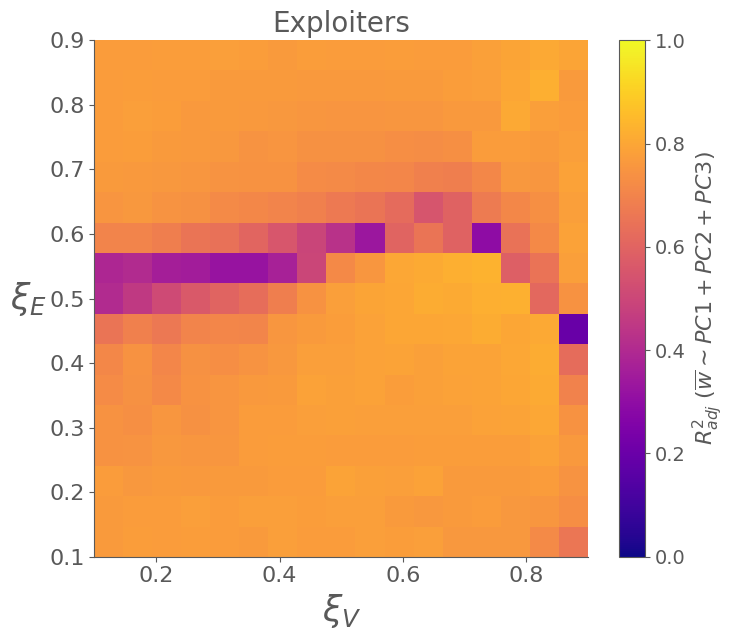

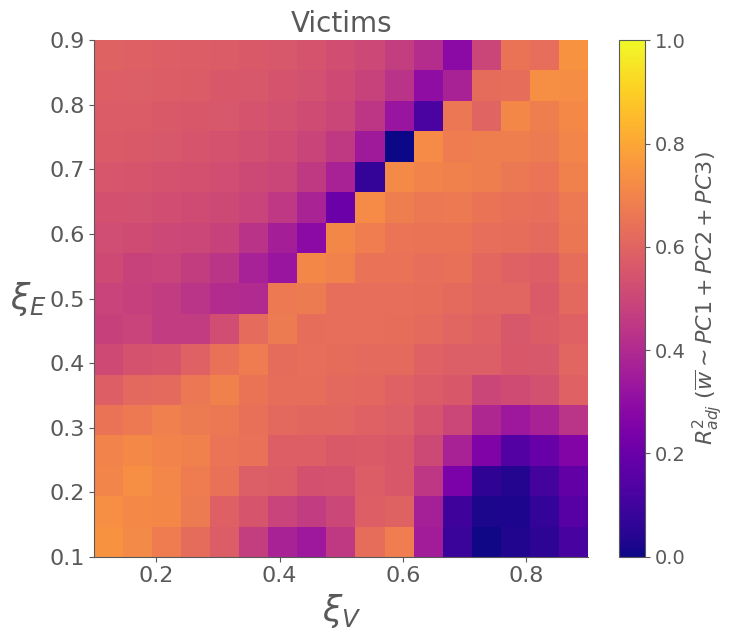

In [16]:
# --- Bloque 2: R2_adj de fitness ~ PC1+PC2+PC3 sobre toda la rejilla (xi_E, xi_V) ---
xi_E_vals = sorted(merged_full["xi_E"].unique())
xi_V_vals = sorted(merged_full["xi_V"].unique())


def r2_adj_grid(y, X_const):
    n, p = X_const.shape
    beta, *_ = np.linalg.lstsq(X_const, y, rcond=None)
    resid = y - X_const @ beta
    r2 = 1 - np.sum(resid ** 2) / np.sum((y - y.mean()) ** 2)
    return 1 - (1 - r2) * (n - 1) / (n - p)


# Las PCs no dependen del régimen (xi_E, xi_V) -> se estandarizan una sola vez.
pc_ref = merged_full[(merged_full["species_type"] == "E") & (merged_full["xi_E"] == xi_E_vals[0])
                      & (merged_full["xi_V"] == xi_V_vals[0])].sort_values("network")
Xz_ref = (pc_ref[PC_COLS] - pc_ref[PC_COLS].mean()) / pc_ref[PC_COLS].std()
X_const_grid = sm.add_constant(Xz_ref.values)

r2_grid = {g: np.full((len(xi_E_vals), len(xi_V_vals)), np.nan) for g in GREMIOS}
for gremio in GREMIOS:
    sub_g = merged_full[merged_full["species_type"] == gremio]
    for i, xi_e in enumerate(xi_E_vals):
        for j, xi_v in enumerate(xi_V_vals):
            sub = sub_g[(sub_g["xi_E"] == xi_e) & (sub_g["xi_V"] == xi_v)].sort_values("network")
            r2_grid[gremio][i, j] = r2_adj_grid(sub["w_avg"].values, X_const_grid)

heatmap_titles = {"E": "Exploiters", "V": "Victims"}
heatmap_files = {"E": "r2_heatmap_exploiter", "V": "r2_heatmap_victim"}

for gremio in GREMIOS:
    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    im = ax.imshow(r2_grid[gremio], origin="lower", cmap="plasma", aspect="auto", vmin=0, vmax=1,
                    extent=[min(xi_V_vals), max(xi_V_vals), min(xi_E_vals), max(xi_E_vals)])
    ax.set_xlabel(r"$\xi_V$", fontsize=25)
    ax.set_ylabel(r"$\xi_E$", fontsize=25, rotation=0, labelpad=15, va="center")
    ax.tick_params(axis="both", labelsize=16, colors=grey_color)
    ax.set_title(f"{heatmap_titles[gremio]}", fontsize=20, color=grey_color)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"$R^2_{adj}$ ($\overline{w} \sim PC1+PC2+PC3$)", fontsize=16)
    cbar.ax.tick_params(labelsize=14)
    plt.tight_layout()
    for ext in ["png", "pdf"]:
        fig.savefig(f"{FIGURES_DIR}/{heatmap_files[gremio]}.{ext}", dpi=300, transparent=True)
    plt.show()

### 4. Test de permutación

Para los 4 escenarios límite y cada gremio: R² ajustado observado del modelo
`w_avg ~ PC1 + PC2 + PC3` frente a la distribución nula obtenida barajando la
asignación de fitness a redes (coordenadas PCA fijas), 5000 permutaciones.

In [17]:
# --- Bloque 4: test de permutación (5000 barajados) del R2_adj observado ---
N_PERM = 5000
rng = np.random.default_rng(0)

perm_rows = []
for xi_e, xi_v in CORNER_REGIMES:
    for gremio in GREMIOS:
        sub = merged_full[(merged_full["xi_E"] == xi_e) & (merged_full["xi_V"] == xi_v)
                           & (merged_full["species_type"] == gremio)].sort_values("network")
        y_obs = sub["w_avg"].values
        Xz = (sub[PC_COLS] - sub[PC_COLS].mean()) / sub[PC_COLS].std()
        X_const = sm.add_constant(Xz.values)
        r2_obs = r2_adj_grid(y_obs, X_const)

        r2_perm = np.empty(N_PERM)
        for k in range(N_PERM):
            r2_perm[k] = r2_adj_grid(rng.permutation(y_obs), X_const)
        p_emp = np.mean(r2_perm >= r2_obs)

        perm_rows.append({"regimen": f"xiE={xi_e:.1f}_xiV={xi_v:.1f}", "gremio": gremio,
                           "R2_adj_observado": r2_obs, "p_valor_empirico": p_emp,
                           "n_permutaciones": N_PERM})

perm_table = pd.DataFrame(perm_rows)
print(perm_table.round(4).to_string(index=False))
perm_table.round(4).to_csv(f"{FIGURES_DIR}/pca_fitness_permutation_test.csv", index=False)
perm_table

        regimen gremio  R2_adj_observado  p_valor_empirico  n_permutaciones
xiE=0.1_xiV=0.1      E            0.7677            0.0000             5000
xiE=0.1_xiV=0.1      V            0.7425            0.0000             5000
xiE=0.9_xiV=0.1      E            0.7712            0.0000             5000
xiE=0.9_xiV=0.1      V            0.5947            0.0000             5000
xiE=0.1_xiV=0.9      E            0.6595            0.0000             5000
xiE=0.1_xiV=0.9      V            0.1161            0.0006             5000
xiE=0.9_xiV=0.9      E            0.7935            0.0000             5000
xiE=0.9_xiV=0.9      V            0.7433            0.0000             5000


,regimen,gremio,R2_adj_observado,p_valor_empirico,n_permutaciones
0,xiE=0.1_xiV=0.1,E,0.767709,0.0000,5000
1,xiE=0.1_xiV=0.1,V,0.742473,0.0000,5000
2,xiE=0.9_xiV=0.1,E,0.771222,0.0000,5000
3,xiE=0.9_xiV=0.1,V,0.594727,0.0000,5000
4,xiE=0.1_xiV=0.9,E,0.659453,0.0000,5000
5,xiE=0.1_xiV=0.9,V,0.116134,0.0006,5000
6,xiE=0.9_xiV=0.9,E,0.793496,0.0000,5000
7,xiE=0.9_xiV=0.9,V,0.743272,0.0000,5000


### 5. Robustez: regresión beta (check)

Repite la regresión del bloque 1 con un modelo de regresión beta (link logit
en la media, log en la precisión; MLE vía `scipy.optimize.minimize`, sin
librería nativa de regresión beta disponible en el entorno) y compara el
signo y la significancia de PC1 frente a la OLS.

In [18]:
# --- Bloque 5: regresión beta como check de robustez de la OLS del bloque 1 ---
from scipy.optimize import minimize
from scipy.special import expit, gammaln
from statsmodels.tools.numdiff import approx_hess


def _beta_neg_loglik(params, y, X):
    k = X.shape[1]
    b, log_phi = params[:k], params[k]
    phi = np.exp(log_phi)
    mu = np.clip(expit(X @ b), 1e-6, 1 - 1e-6)
    a, bb = mu * phi, (1 - mu) * phi
    ll = gammaln(phi) - gammaln(a) - gammaln(bb) + (a - 1) * np.log(y) + (bb - 1) * np.log(1 - y)
    return -np.sum(ll)


def fit_beta_regression(y, X_const):
    """MLE de una regresión beta (link logit en la media, log en la precision)."""
    k = X_const.shape[1]
    x0 = np.zeros(k + 1)
    x0[0] = np.log(y.mean() / (1 - y.mean()))
    x0[-1] = 2.0
    res = minimize(_beta_neg_loglik, x0, args=(y, X_const), method="BFGS")
    hess = approx_hess(res.x, _beta_neg_loglik, args=(y, X_const))
    se = np.sqrt(np.diag(np.linalg.inv(hess)))
    p_vals = 2 * (1 - stats.norm.cdf(np.abs(res.x / se)))
    return res.x[:k], p_vals[:k]


beta_rows = []
for xi_e, xi_v in CORNER_REGIMES:
    for gremio in GREMIOS:
        sub = merged_full[(merged_full["xi_E"] == xi_e) & (merged_full["xi_V"] == xi_v)
                           & (merged_full["species_type"] == gremio)].sort_values("network")
        y = sub["w_avg"].values
        Xz = (sub[PC_COLS] - sub[PC_COLS].mean()) / sub[PC_COLS].std()
        X_const = sm.add_constant(Xz.values)

        regimen_key = f"xiE={xi_e:.1f}_xiV={xi_v:.1f}"
        ols_pc1 = summary_table[(summary_table["regimen"] == regimen_key)
                                 & (summary_table["gremio"] == gremio) & (summary_table["PC"] == "PC1")].iloc[0]
        beta_coefs, beta_pvals = fit_beta_regression(y, X_const)
        beta_rows.append({
            "regimen": regimen_key, "gremio": gremio,
            "PC1_beta_std_OLS": ols_pc1["beta_std"], "PC1_p_OLS": ols_pc1["p_valor"],
            "PC1_coef_betareg": beta_coefs[1], "PC1_p_betareg": beta_pvals[1],
        })

beta_check_table = pd.DataFrame(beta_rows)
beta_check_table["signo_coincide"] = (np.sign(beta_check_table["PC1_beta_std_OLS"])
                                       == np.sign(beta_check_table["PC1_coef_betareg"]))
beta_check_table["significancia_coincide"] = ((beta_check_table["PC1_p_OLS"] < 0.05)
                                               == (beta_check_table["PC1_p_betareg"] < 0.05))
print(beta_check_table.round(4).to_string(index=False))

if beta_check_table["signo_coincide"].all() and beta_check_table["significancia_coincide"].all():
    print("\nRobustez: el signo y la significancia de PC1 coinciden entre OLS y regresion beta "
          "en los 4 escenarios limite x 2 gremios; el resultado del bloque 1 es robusto a la "
          "especificacion de la distribucion condicional de la fitness.")
else:
    print("\nAtencion: OLS y regresion beta difieren en signo o significancia de PC1 en algun "
          "escenario -- revisar antes de reportar robustez.")

        regimen gremio  PC1_beta_std_OLS  PC1_p_OLS  PC1_coef_betareg  PC1_p_betareg  signo_coincide  significancia_coincide
xiE=0.1_xiV=0.1      E            0.1097     0.0000            0.5242         0.0000            True                    True
xiE=0.1_xiV=0.1      V            0.0304     0.0000            0.1554         0.0000            True                    True
xiE=0.9_xiV=0.1      E           -0.0105     0.0000           -0.3666         0.0000            True                    True
xiE=0.9_xiV=0.1      V           -0.1282     0.0000           -0.8564         0.0000            True                    True
xiE=0.1_xiV=0.9      E            0.0713     0.0000            0.4917         0.0000            True                    True
xiE=0.1_xiV=0.9      V           -0.0008     0.7717           -0.0029         0.8827            True                    True
xiE=0.9_xiV=0.9      E           -0.0887     0.0000           -0.4369         0.0000            True                    True
